In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json

from constants import AnnotationsReduced
from model_utils import *

from ast import literal_eval
from pathlib import Path

import numpy as np

In [2]:
plt.style.use('ggplot')
sns.set_palette('hls')
SPLIT = 'test'

In [3]:
target_columns = AnnotationsReduced.model_fields.keys()

reg_fields = get_regression_fields(AnnotationsReduced)
cl_fields = get_classification_fields(AnnotationsReduced)
mc_fields = get_multiple_choice_fields(AnnotationsReduced)
bc_fields = get_binary_classification_fields(AnnotationsReduced)
label_to_id_map = create_label_to_id_map(AnnotationsReduced)

In [4]:
##############
# Load metrics
##############

bl_most_frequent = pd.read_csv(f'baseline_most_frequent_metrics_{SPLIT}.csv', index_col=0)

bl_uniform = pd.read_csv(f'baseline_uniform_metrics_{SPLIT}.csv', index_col=0)

bl_stratified = pd.read_csv(f'baseline_stratified_metrics_{SPLIT}.csv', index_col=0)
mistral_10 = pd.read_csv(f'mistral_10_metrics_{SPLIT}.csv', index_col=0)
mistral_30 = pd.read_csv(f'mistral_30_metrics_{SPLIT}.csv', index_col=0)

dfs = {
    'most_frequent': bl_most_frequent,
    'uniform': bl_uniform,
    'stratified': bl_stratified,
    'mistral_10': mistral_10,
    'mistral_30': mistral_30
}

In [5]:
def plot_grouped_barchart(fields: list[str], models: list[str], metric: str = 'f1_macro', res_dict=dfs) -> None:
    values: dict[str, list] = {
        model: round(res_dict[model].loc[fields, metric], 2).to_list() for model in models
    }
    x = np.arange(len(fields))
    n_models = len(models)
    width = 0.8 / n_models
    
    offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, n_models)

    fig, ax = plt.subplots(layout='constrained', figsize=(14, 5))
    #fig, ax = plt.subplots(layout='constrained')
    
    for offset, (model, v) in zip(offsets, values.items()):
        rects = ax.bar(x + offset, v, width, label=model)
        ax.bar_label(rects, padding=3)
        
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by models')
    ax.set_xticks(x, fields)
    #ax.legend(loc='upper left', ncols=3)
    ax.legend()
    #ax.set_ylim(0, 1)
    
    plt.show()

# Multi-class fields

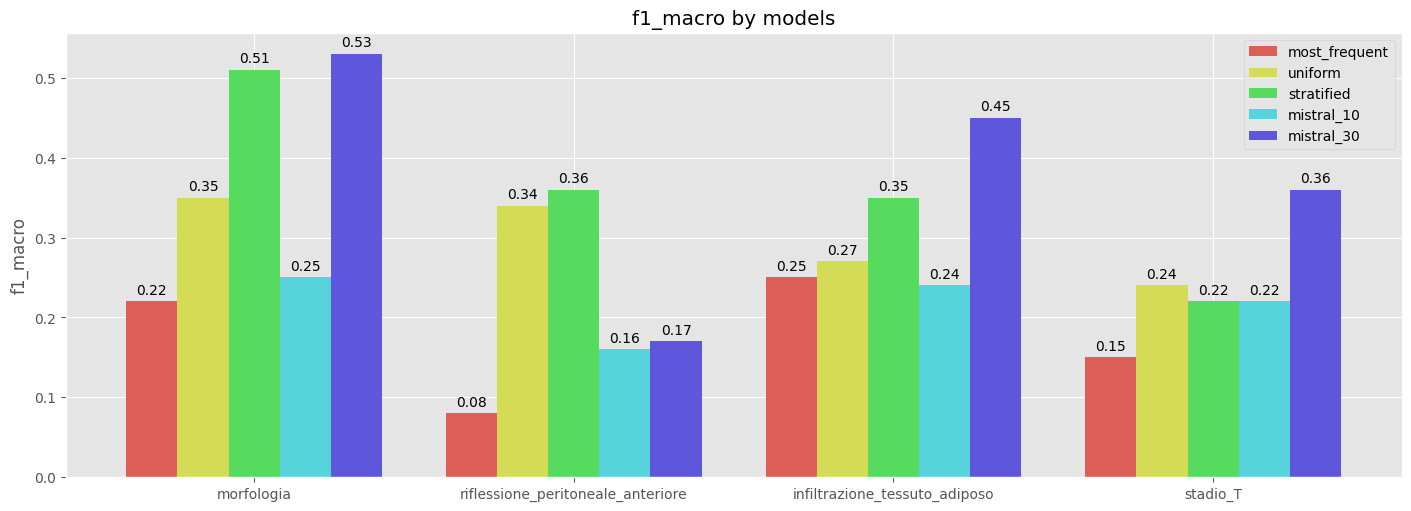

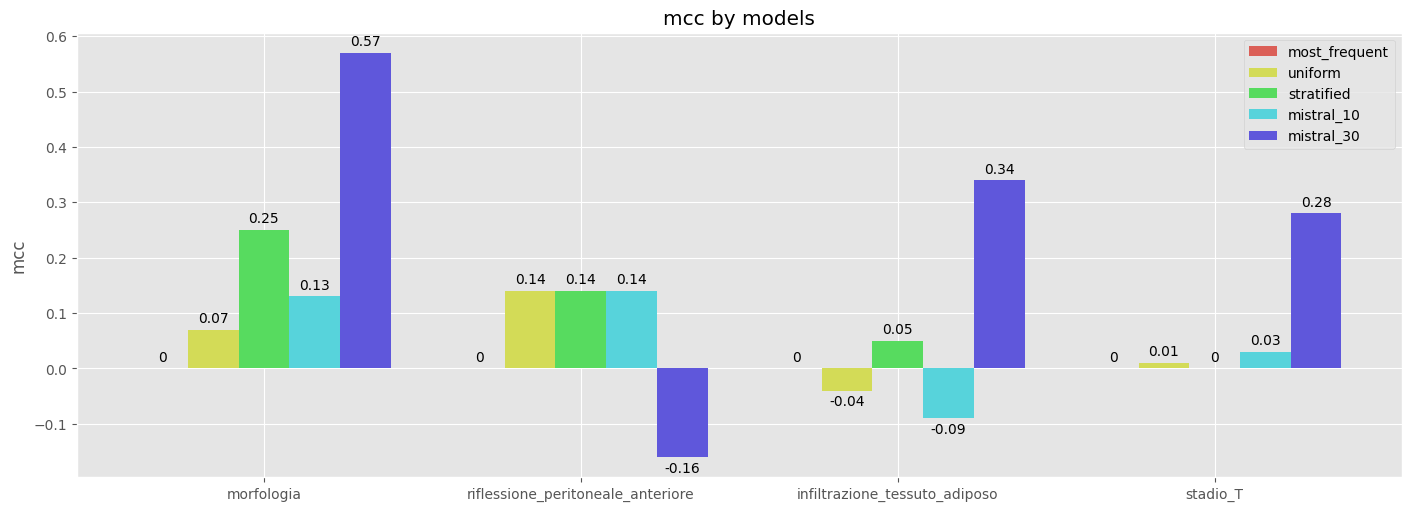

In [6]:
plot_models = [
    'most_frequent',
    'uniform',
    'stratified',
    'mistral_10',
    'mistral_30'
]
plot_fieds = cl_fields

plot_grouped_barchart(plot_fieds, plot_models)
plot_grouped_barchart(plot_fieds, plot_models, metric='mcc')

# Binary fields

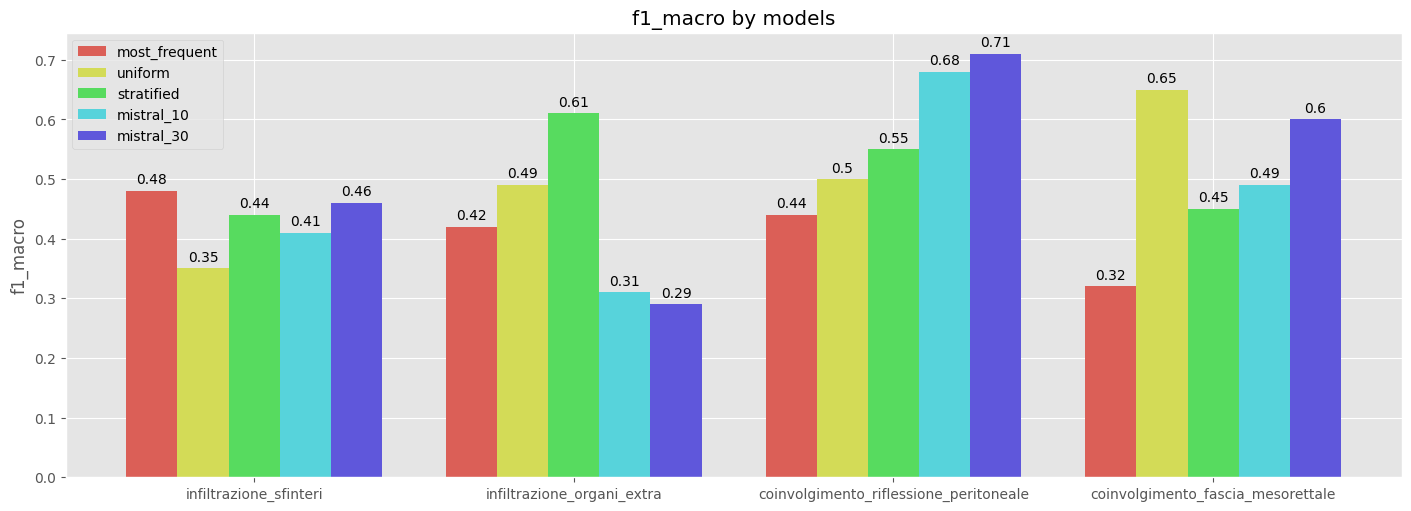

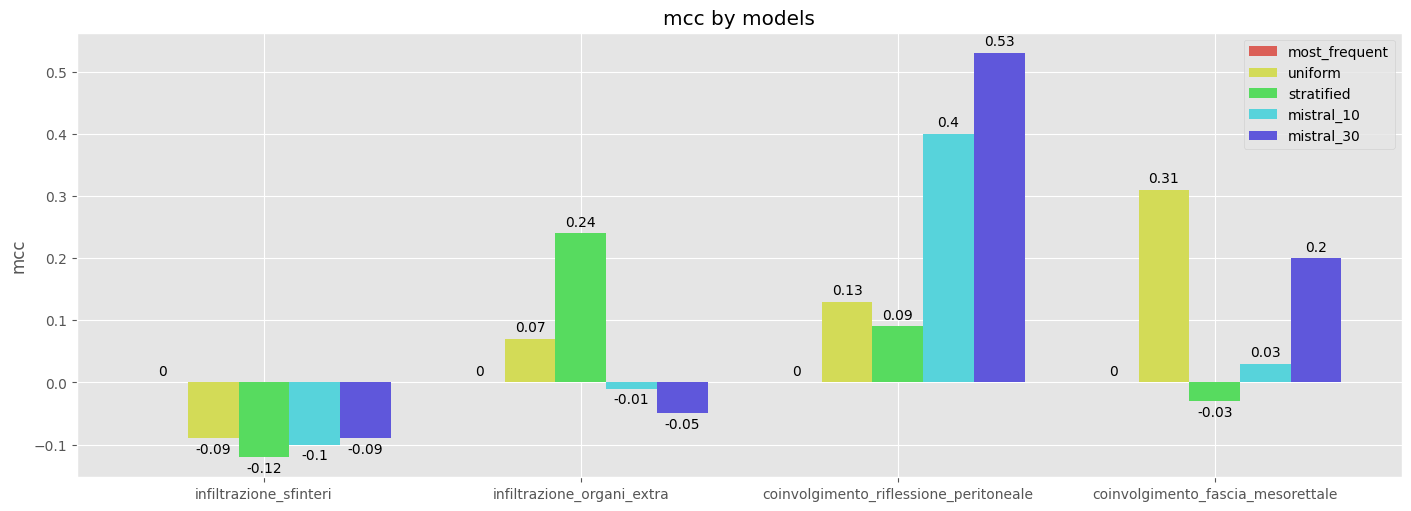

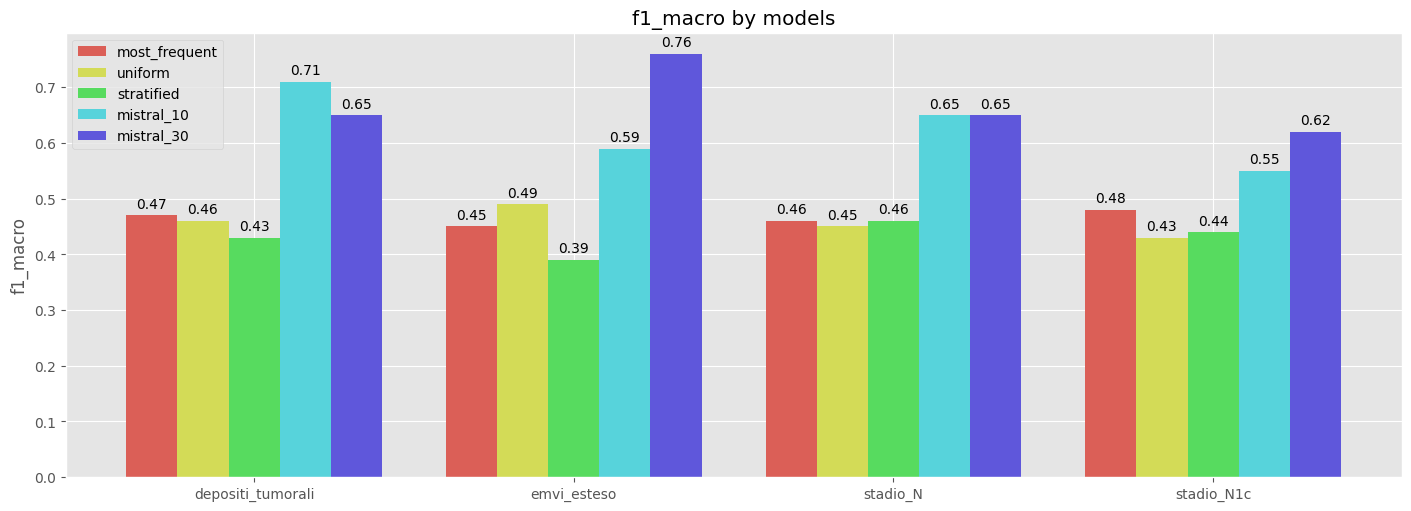

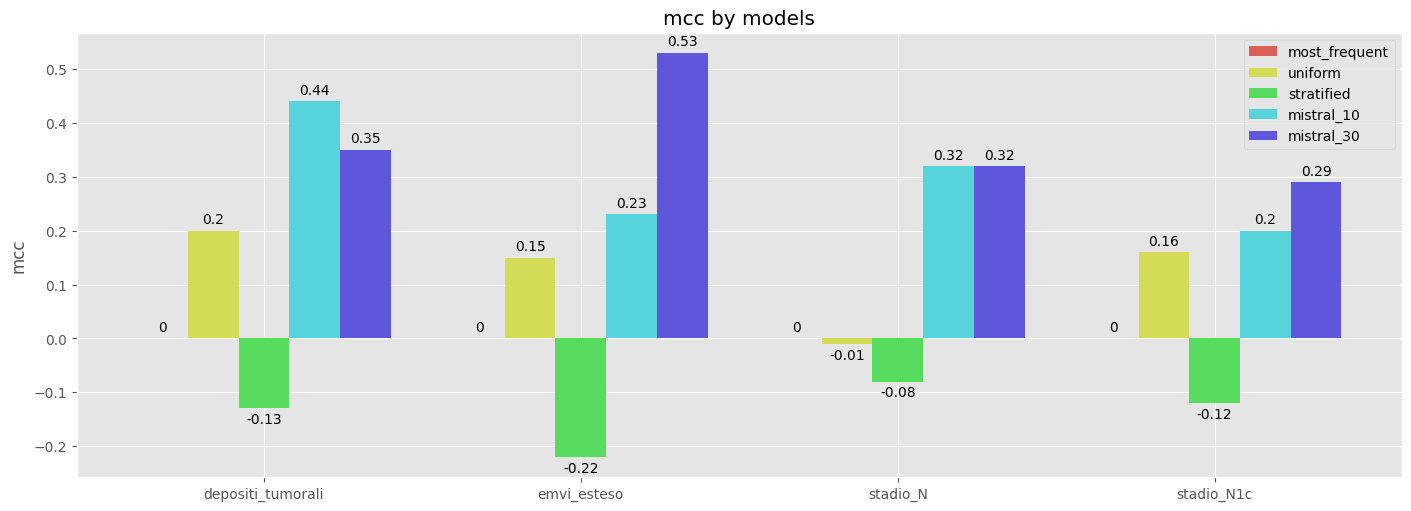

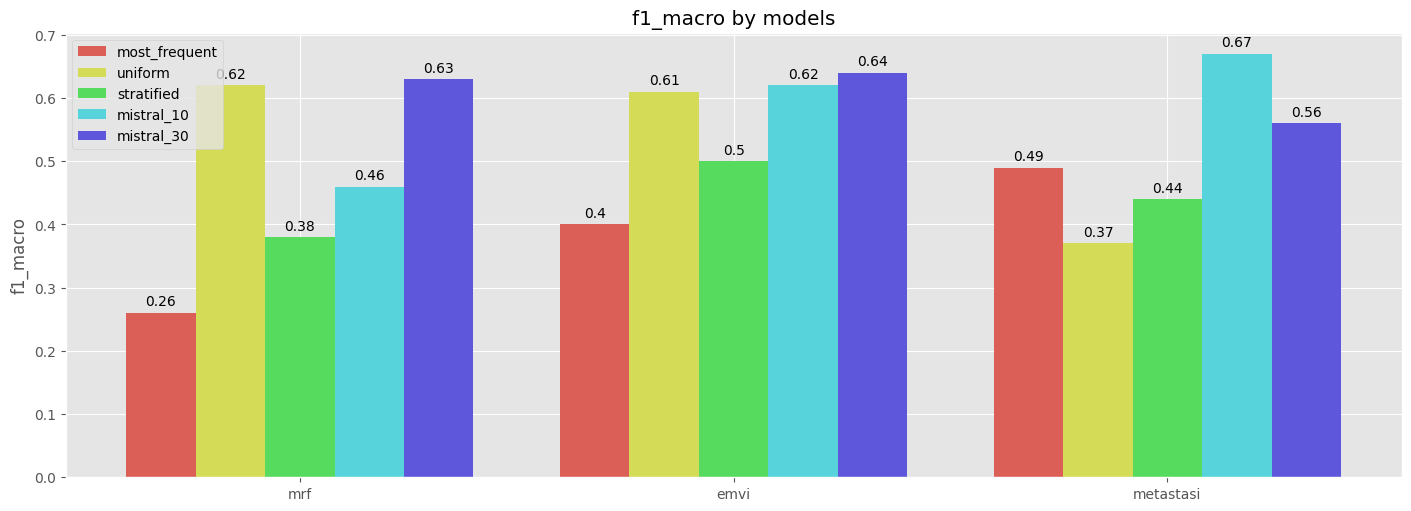

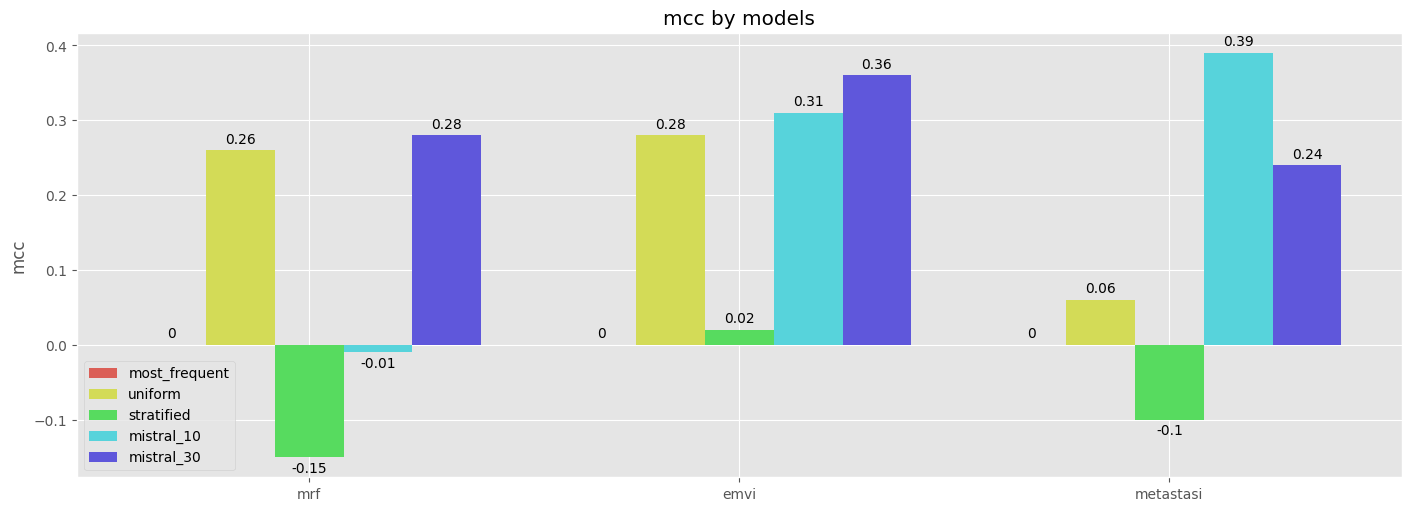

In [7]:
plot_models = [
    'most_frequent',
    'uniform',
    'stratified',
    'mistral_10',
    'mistral_30'
]
plot_fieds = bc_fields[:4]
plot_grouped_barchart(plot_fieds, plot_models)
plot_grouped_barchart(plot_fieds, plot_models, metric='mcc')

plot_fieds = bc_fields[4:8]
plot_grouped_barchart(plot_fieds, plot_models)
plot_grouped_barchart(plot_fieds, plot_models, metric='mcc')

plot_fieds = bc_fields[8:]
plot_grouped_barchart(plot_fieds, plot_models)
plot_grouped_barchart(plot_fieds, plot_models, metric='mcc')

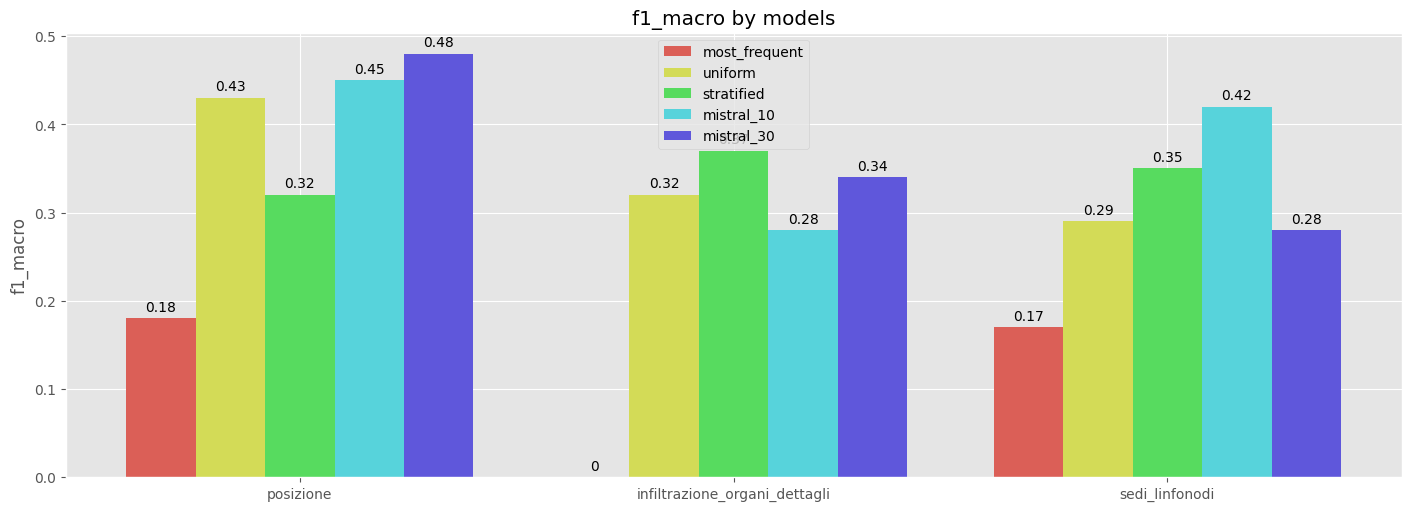

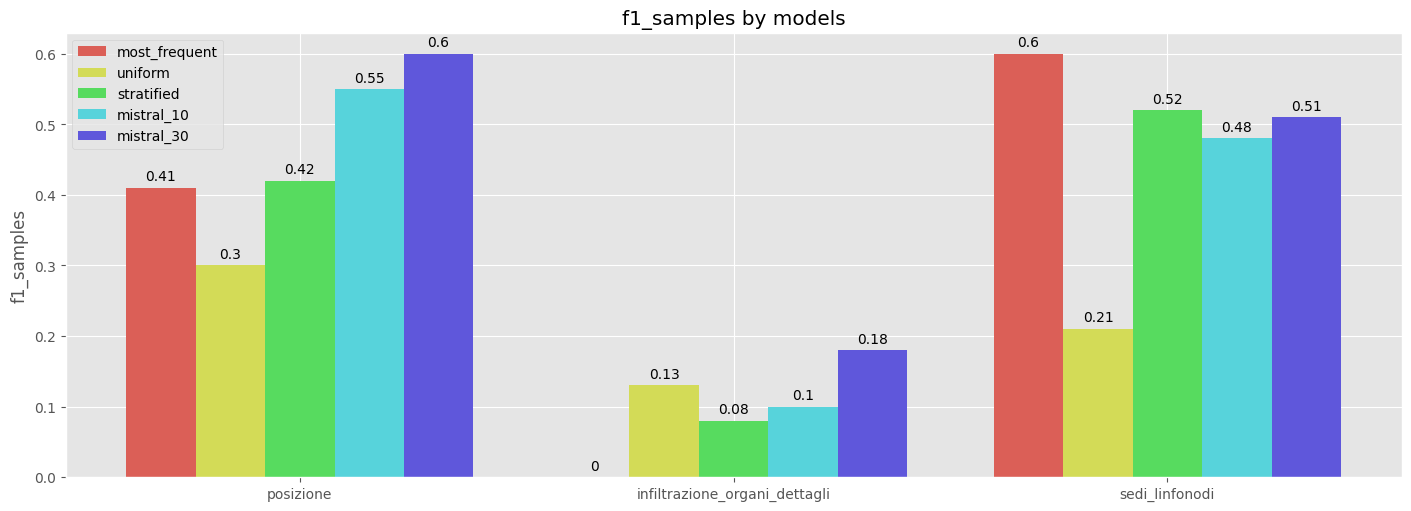

In [8]:
plot_models = [
    'most_frequent',
    'uniform',
    'stratified',
    'mistral_10',
    'mistral_30'
]
plot_fieds = mc_fields

plot_grouped_barchart(plot_fieds, plot_models)
plot_grouped_barchart(plot_fieds, plot_models, metric='f1_samples')